# Combine Datasets

In [1]:
import os
import pandas as pd

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ausgrid_solar_home_data')

# Load processed datasets
ausgrid = pd.read_csv(os.path.join(data_dir, "ausgrid_processed.csv"))
weather = pd.read_csv(os.path.join(data_dir, "weather_data_processed.csv"))

# Combine datasets
df = ausgrid.merge(weather, on="datetime", how="left")
df.head()

,Customer,Generator Capacity,Postcode,Consumption Category,datetime,kWh,Unnamed: 0,temperature_2m,shortwave_radiation,precipitation
0,1,3.78,2076,CL,2010-07-01 00:00:00,1.075,0.0,3.60,0.0,0.0
1,1,3.78,2076,CL,2010-07-01 00:30:00,1.250,1.0,3.45,0.0,0.0
2,1,3.78,2076,CL,2010-07-01 01:00:00,1.244,2.0,3.30,0.0,0.0
3,1,3.78,2076,CL,2010-07-01 01:30:00,1.256,3.0,2.75,0.0,0.0
4,1,3.78,2076,CL,2010-07-01 02:00:00,0.744,4.0,2.20,0.0,0.0


The Ausgrid dataset uses three consumption categories:
- GC: General Consumption
- CL: Controlled Load
- GG: Gross Generation (solar PV generation)

Consider a real distribution system. Net load is monitored for each customer, but residential solar generation may not be directly measured. The size, orientation, and other characteristics of the solar installations may also be unknown.
Our goal is to disaggregate net load into base load and PV generation. Net load is given by $P_\text{net} = P_\text{load} - P_\text{PV}$ where $P_\text{load} = GC + CL$.
We can do this by predicting $P_\text{PV}$.

A common simplified equation for PV power output is:

$P_\text{PV} = P_\text{rated} \frac{G}{G_\text{STC}}[1 + \gamma (T_\text{cell} - T_\text{STC})]$
- $P_\text{PV}$ = PV electrical power output (kW).
- $P_\text{rated}$ = rated/nominal PV system capacity (kW).
- G = indicent solar irradiance on the panels (W/m^2).
- $G_\text{STC}$ = reference irradiance at standard test conditions, typically 1000 W/m^2.
- $T_\text{cell}$ = PV cell temperature (C)
- $T_\text{STC}$ = reference cell temperature, typically 25 C.
- $\gamma$ = temperature coefficient of power (per C), normally negative.

Irradiance primarily determines how much power is available, where cell temperature modifies the output. Solar irradiance is the solar power received per unit area, typically measured in W/m^2. For PV modeling, it ideally refers to the radiation incident on the panel surface. Shortwave radiation is a broader atmospheric measurement of incoming radiation in the shortwave portion of the spectrum, also measured in W/m^2. In our dataset, `shortwave_radiation` can serve as a proxy for the solar irradiance available to the PV system.

The rated PV system capacity $P_\text{rated}$ is unknown. The incident solar radiation $G$ can be estimated from `shortwave_radiation` and the position of the sun, which can in turn be estimated from the `hour of day` and the `geographical location` of the system. A useful starting point to to model the irradiance incident on the PV panels as:

$G(t) = S(t) f(\theta_\text{sun}(t, \phi, \lambda), \beta)$
- $G(t)$ = irradiance incident on the PV panels at time t (W/m^2)
- $S(t)$ = measured shortwave radiation (W/m^2)
- t = time of day/date.
- $\phi, \lambda$ = latitude and longitude of the PV system.
- $\theta_\text{sun}$ = solar position.
- $\beta$ = panel tilt, which is unknown and must be estimated.
- $f(\dot)$ = function describing how solar position and panel orientation determine the radiation incident on the panel.

$\theta_\text{sun} = \sin \phi \sin \delta + \cos \phi \cos \delta \cos H$
- $\delta$ = solar declination, determined by the date.
- $H$ = solar hour angle, determined by time of day.

$\delta = 23.45 \degree \sin (\frac{360 \degree}{365}(284 + n))$
- $n$ = day of year (1-365)

$f(\theta_\text{sun}, \beta) = \max (0, \cos(\theta_\text{sun} - \beta))$

The expression for $P_\text{PV}$ becomes:

$P_\text{PV} = P_\text{rated} \times \frac{ S(t) \max(0, \cos(\theta_\text{sun} - \beta))}{G_\text{STC}} [1 + \gamma(T_\text{cell} - T_\text{STC})]$

Replace $P_\text{rated}$ with parameter $\alpha$ which represents unknown characteristics of the PV system affecting maximum output, such as area and number of panels. The parameter $\beta$ represents the unknown angle of the panels. The parameter $\gamma$ represents the unknown temperature coefficient of power. 

## Calculate Sun Position

In [2]:
import numpy as np
import pandas as pd

lat = 33.9 # system latitude (degrees)
lon = 151.2 # system longitude (degrees)

# Convert string to datetime type
df["datetime"] = pd.to_datetime(df["datetime"])

sun = pd.DataFrame({"datetime": df["datetime"]})
sun["day_of_year"] = sun["datetime"].dt.dayofyear
sun["hour"] = sun["datetime"].dt.hour + sun["datetime"].dt.minute / 60

# Solar declination
sun["declination_angle"] = np.radians(23.45 * np.sin(np.radians((360 / 365) * (284 + sun["day_of_year"]))))

# Solar hour angle (simplified: 15° per hour from solar noon)
hour_angle = np.radians(15 * (sun['hour'] - 12))

# Solar zenith angle
lat_rad = np.radians(lat)
sun["sun_position"] = np.degrees(np.arccos(
    np.sin(lat_rad) * np.sin(sun["declination_angle"]) +
    np.cos(lat_rad) * np.cos(sun["declination_angle"]) * np.cos(hour_angle)))

# Make sure sun does not have duplicate datetime values
sun = sun[["datetime", "sun_position"]].drop_duplicates("datetime")

sun.head()

,datetime,sun_position
0,2010-07-01 00:00:00,122.979516
1,2010-07-01 00:30:00,122.534587
2,2010-07-01 01:00:00,121.220214
3,2010-07-01 01:30:00,119.093277
4,2010-07-01 02:00:00,116.236036


### Append sun position to original dataset

In [3]:
df = df.merge(
    sun[["datetime", "sun_position"]],
    on="datetime",
    how="left")

df.head()

,Customer,Generator Capacity,Postcode,Consumption Category,datetime,kWh,Unnamed: 0,temperature_2m,shortwave_radiation,precipitation,sun_position
0,1,3.78,2076,CL,2010-07-01 00:00:00,1.075,0.0,3.60,0.0,0.0,122.979516
1,1,3.78,2076,CL,2010-07-01 00:30:00,1.250,1.0,3.45,0.0,0.0,122.534587
2,1,3.78,2076,CL,2010-07-01 01:00:00,1.244,2.0,3.30,0.0,0.0,121.220214
3,1,3.78,2076,CL,2010-07-01 01:30:00,1.256,3.0,2.75,0.0,0.0,119.093277
4,1,3.78,2076,CL,2010-07-01 02:00:00,0.744,4.0,2.20,0.0,0.0,116.236036


Our model is simplified to:
$P_\text{PV}(t) = C \times S(t) \times \theta_\text{sun}(t) \frac{1 + \gamma (T_\text{Cell}(t) - T_\text{STC})}{G_\text{STC}}$
- $S(t)$ is `shortwave_radiation`.
- $\theta_\text{sun}(t)$ is the position of the sun
- $T_\text{cell}(t)$ is estimated as `temperature_2m`.
- $T_\text{STC}$ and $G_\text{STC}$ are known constants.
- $C$ is a per-customer unknown parameter accounting for PV system characteristics such as total generating capacity and panel tilt angle.
- $\gamma$ is a per-customer unknown parameter representing the PV system's temperature coefficient of power (per C).

# Parameter Estimation
## Modify the dataset

In [4]:
df["Pload"] = df["kWh"].where(df["Consumption Category"].isin(["GC", "CL"]), 0)
df["PPV"]   = df["kWh"].where(df["Consumption Category"] == "GG", 0)
df["Pnet"]  = df["Pload"] - df["PPV"]
df.drop(columns=["Consumption Category", "kWh"], inplace=True)
df.head()

,Customer,Generator Capacity,Postcode,datetime,Unnamed: 0,temperature_2m,shortwave_radiation,precipitation,sun_position,Pload,PPV,Pnet
0,1,3.78,2076,2010-07-01 00:00:00,0.0,3.60,0.0,0.0,122.979516,1.075,0.0,1.075
1,1,3.78,2076,2010-07-01 00:30:00,1.0,3.45,0.0,0.0,122.534587,1.250,0.0,1.250
2,1,3.78,2076,2010-07-01 01:00:00,2.0,3.30,0.0,0.0,121.220214,1.244,0.0,1.244
3,1,3.78,2076,2010-07-01 01:30:00,3.0,2.75,0.0,0.0,119.093277,1.256,0.0,1.256
4,1,3.78,2076,2010-07-01 02:00:00,4.0,2.20,0.0,0.0,116.236036,0.744,0.0,0.744


## Remove Missing Data

In [7]:
# Remove the unnamed column
df = df.drop(columns=["Unnamed: 0"])

# Remove rows containing any missing values
df = df.dropna()

# Count NaNs in each column
display(df.isna().sum())

Customer               0
Generator Capacity     0
Postcode               0
datetime               0
temperature_2m         0
shortwave_radiation    0
precipitation          0
sun_position           0
Pload                  0
PPV                    0
Pnet                   0
dtype: int64

## Split Training and Testing Data

In [81]:
# Randomly split each customer's data 80/20
train_df = (
    df.groupby("Customer", group_keys=False)
      .sample(frac=0.8, random_state=42))

# Everything not selected for training goes into testing
test_df = df.drop(train_df.index)

# Optional: reset indices
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

## Perform Parameter Estimation

In [82]:
import numpy as np
from scipy.optimize import least_squares

G_STC = 1000
T_STC = 25

def residuals(params, S, theta_sun, T, P):
    alpha, beta, gamma = params

    # Irradiance adjustment for panel tilt
    incidence_factor = np.maximum(0, np.cos(np.radians(theta_sun - beta)))

    # Predicted PV energy (kWh per 30-minute interval)
    P_hat = (
        alpha
        * S / G_STC
        * incidence_factor
        * (1 + gamma * (T - T_STC))
        * 0.5)

    return P_hat - P

results = []

for customer, group in train_df.groupby("Customer"):
    S = group["shortwave_radiation"].values
    theta_sun = group["sun_position"].values
    T = group["temperature_2m"].values
    P = group["PPV"].values

    # Initial guesses: capacity, panel tilt, temperature coefficient
    initial_guess = [
        group["Generator Capacity"].iloc[0],
        30,
        -0.004]

    # Estimate alpha, beta, and gamma
    fit = least_squares(
        residuals,
        x0=initial_guess,
        bounds=(
            [0, 0, -0.02],
            [np.inf, 90, 0.02]),
        args=(S, theta_sun, T, P))

    results.append([
        customer,
        fit.x[0],
        fit.x[1],
        fit.x[2]])

parameters = pd.DataFrame(
    results,
    columns=["Customer", "alpha", "beta", "gamma"])

parameters.head()

,Customer,alpha,beta,gamma
0,1,1.119017,35.992530,0.006523
1,2,0.481045,25.803825,-0.017665
2,3,0.338140,31.152128,-0.001233
3,4,0.270474,35.361862,-0.007458
4,5,0.265757,32.845339,-0.007325


## Train Results

In [83]:
display(parameters.columns)

Index(['Customer', 'alpha', 'beta', 'gamma'], dtype='str')

In [84]:
# Remove existing parameter columns
train_df = train_df.drop(
    columns=["alpha", "beta", "gamma"],
    errors="ignore")

# Add updated parameters
train_df = train_df.merge(
    parameters[["Customer", "alpha", "beta", "gamma"]],
    on="Customer",
    how="left")

# Remove duplicate customer-datetime observations
train_df = train_df.drop_duplicates(subset=["Customer", "datetime"])

# Sort chronologically within each customer
train_df = train_df.sort_values(["Customer", "datetime"]).reset_index(drop=True)

train_df.head()

,Customer,Generator Capacity,Postcode,datetime,temperature_2m,shortwave_radiation,precipitation,sun_position,Pload,PPV,Pnet,alpha,beta,gamma
0,1,3.78,2076,2010-07-01 00:00:00,3.60,0.0,0.0,122.979516,1.075,0.0,1.075,1.119017,35.99253,0.006523
1,1,3.78,2076,2010-07-01 00:30:00,3.45,0.0,0.0,122.534587,0.000,0.0,0.000,1.119017,35.99253,0.006523
2,1,3.78,2076,2010-07-01 01:00:00,3.30,0.0,0.0,121.220214,0.471,0.0,0.471,1.119017,35.99253,0.006523
3,1,3.78,2076,2010-07-01 01:30:00,2.75,0.0,0.0,119.093277,0.083,0.0,0.083,1.119017,35.99253,0.006523
4,1,3.78,2076,2010-07-01 02:00:00,2.20,0.0,0.0,116.236036,0.744,0.0,0.744,1.119017,35.99253,0.006523


In [85]:
# Panel incidence factor
incidence_factor = np.maximum(0,np.cos(np.radians(train_df["sun_position"] - train_df["beta"])))

# Predict PV generation
train_df["PPV_pred"] = (
    train_df["alpha"]
    * train_df["shortwave_radiation"] / 1000
    * incidence_factor
    * (1 + train_df["gamma"] * (train_df["temperature_2m"] - 25))
    * 0.5)

# Compare predicted vs. true PV generation
comparison = train_df[["Customer", "PPV", "PPV_pred"]]
comparison.head()

,Customer,PPV,PPV_pred
0,1,0.0,0.0
1,1,0.0,0.0
2,1,0.0,0.0
3,1,0.0,0.0
4,1,0.0,0.0


In [86]:
# Plot
import matplotlib.pyplot as plt
plt.rcParams["agg.path.chunksize"] = 10000

customer = train_df["Customer"].iloc[0]
plot_df = (
    train_df[train_df["Customer"] == customer]
    .sort_values("datetime"))

plot_df.head()

,Customer,Generator Capacity,Postcode,datetime,temperature_2m,shortwave_radiation,precipitation,sun_position,Pload,PPV,Pnet,alpha,beta,gamma,PPV_pred
0,1,3.78,2076,2010-07-01 00:00:00,3.60,0.0,0.0,122.979516,1.075,0.0,1.075,1.119017,35.99253,0.006523,0.0
1,1,3.78,2076,2010-07-01 00:30:00,3.45,0.0,0.0,122.534587,0.000,0.0,0.000,1.119017,35.99253,0.006523,0.0
2,1,3.78,2076,2010-07-01 01:00:00,3.30,0.0,0.0,121.220214,0.471,0.0,0.471,1.119017,35.99253,0.006523,0.0
3,1,3.78,2076,2010-07-01 01:30:00,2.75,0.0,0.0,119.093277,0.083,0.0,0.083,1.119017,35.99253,0.006523,0.0
4,1,3.78,2076,2010-07-01 02:00:00,2.20,0.0,0.0,116.236036,0.744,0.0,0.744,1.119017,35.99253,0.006523,0.0


C:\Users\codett\AppData\Local\Temp\ipykernel_17656\777822410.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


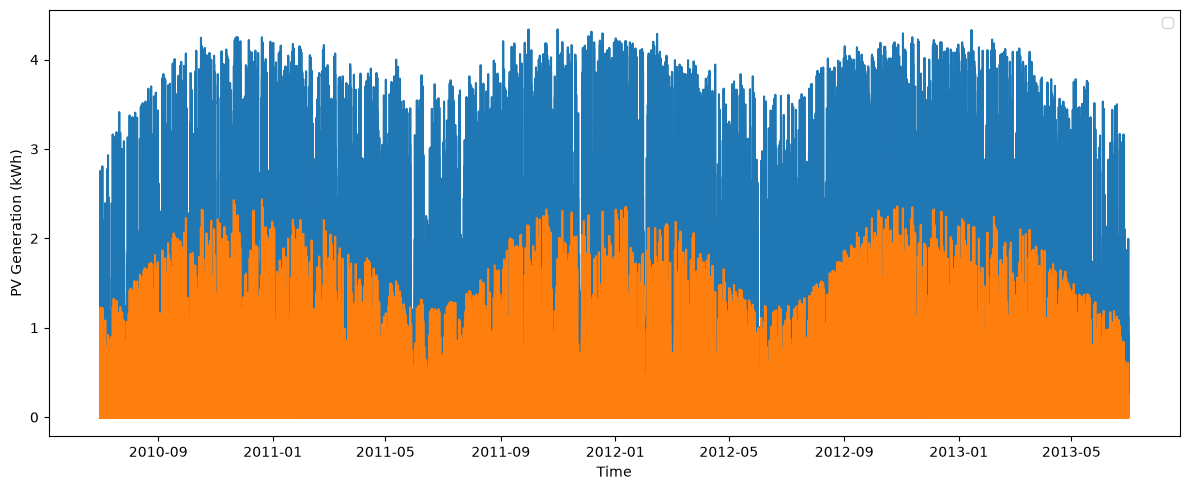

In [89]:
plt.figure(figsize=(12, 5))
plt.plot(train_df["datetime"], train_df["PPV"])
plt.plot(train_df["datetime"], train_df["PPV_pred"])
# plt.plot(train_df["datetime"], train_df["PPV"], label="True PPV")
# plt.plot(train_df["datetime"], train_df["PPV_pred"], label="Predicted PPV")
plt.xlabel("Time")
plt.ylabel("PV Generation (kWh)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

The results on the training data are showing systematic offset. Our first tpe is to check the scale of `alpha` versus `Generator Capacity`. If alpha is consistently smaller than actual generating capacity, that would explain the offset.

In [90]:
check = train_df[["Customer", "Generator Capacity"]].drop_duplicates(
    "Customer").merge(parameters, on="Customer")

check["alpha_ratio"] = check["alpha"] / check["Generator Capacity"]
check[["Generator Capacity", "alpha", "alpha_ratio"]].describe()

,Generator Capacity,alpha,alpha_ratio
count,300.000000,300.000000,300.000000
mean,1.683300,0.602797,0.356433
std,1.036846,0.412600,0.080065
min,1.000000,0.202756,0.174844
25%,1.020000,0.376698,0.292587
50%,1.500000,0.488990,0.339769
75%,2.000000,0.686975,0.422857
max,9.990000,4.509278,0.624316


## Test Results

In [53]:
# Add estimated parameters to test data
test_df = test_df.merge(parameters, on="Customer", how="left")

# Predict PV generation
incidence_factor = np.maximum(0, np.cos(np.radians(test_df["sun_position"] - test_df["beta"])))

test_df["PPV_pred"] = (
    test_df["alpha"]
    * test_df["shortwave_radiation"] / 1000
    * incidence_factor
    * (1 + test_df["gamma"] * (test_df["temperature_2m"] - 25))
    * 0.5)  # convert kW to kWh for 30-minute interval

# Compare predicted vs. true PV generation
comparison = test_df[["Customer", "PPV", "PPV_pred"]]

comparison.head()

,Customer,PPV,PPV_pred
0,1,0.0,0.000000
1,1,0.0,0.000000
2,1,0.0,0.009939
3,1,0.0,0.020990
4,1,0.0,0.091780


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_df["PPV"], test_df["PPV_pred"])
rmse = np.sqrt(mean_squared_error(test_df["PPV"], test_df["PPV_pred"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.059670479868651496
RMSE: 0.13957287352485565


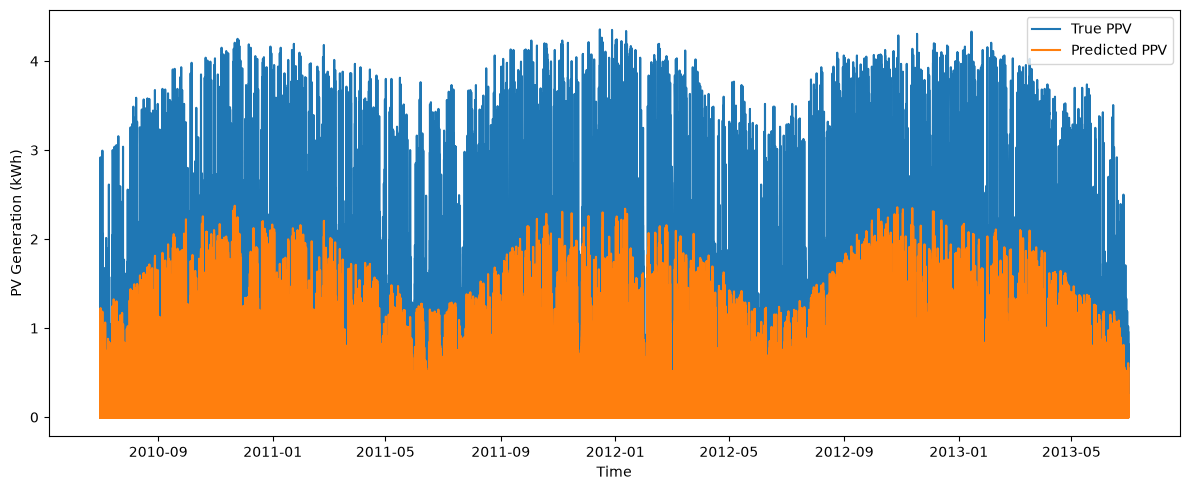

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_df["datetime"], test_df["PPV"], label="True PPV")
plt.plot(test_df["datetime"], test_df["PPV_pred"], label="Predicted PPV")
plt.xlabel("Time")
plt.ylabel("PV Generation (kWh)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()